In [1]:
# Install required packages into the active kernel environment (run once)
%pip install -q lxml matplotlib seaborn pandas numpy scipy pydantic requests tqdm httpx

Note: you may need to restart the kernel to use updated packages.


# Notebook 00 — Setup and Dataset Description

**Abstract:** This notebook verifies the research environment, loads all 4 datasets,
and produces descriptive statistics. It corresponds to **Section 5.1
(Experimental Setup)** of the paper.

**References:**
- El-Sappagh et al. (2011) — A proposed model for data warehouse ETL processes
- Annam (2025) — LLM-Powered Autonomous Agents for ETL Pipeline Generation
- Talaei et al. (2024) — CHESS: Contextual Harnessing for Efficient SQL Synthesis

In [2]:
# Cell 1 — Environment check
%matplotlib inline
import sys
import importlib
import json
import os
from IPython.display import display

# Robustly find research root regardless of kernel start directory
def _find_research_root() -> str:
    sentinel = "generate_datasets.py"
    candidate = os.path.abspath(os.getcwd())
    for _ in range(4):
        if os.path.exists(os.path.join(candidate, sentinel)):
            return candidate
        candidate = os.path.dirname(candidate)
    # Try a 'research' subdirectory of cwd
    sub = os.path.join(os.getcwd(), "research")
    if os.path.exists(os.path.join(sub, sentinel)):
        return os.path.abspath(sub)
    return os.path.abspath(os.getcwd())

RESEARCH_ROOT = _find_research_root()
os.chdir(RESEARCH_ROOT)
if RESEARCH_ROOT not in sys.path:
    sys.path.insert(0, RESEARCH_ROOT)

print(f"Python version: {sys.version}")
print(f"Research root:  {RESEARCH_ROOT}")

# Check dependencies
deps = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'lxml', 'httpx']
for dep in deps:
    try:
        mod = importlib.import_module(dep)
        ver = getattr(mod, '__version__', 'OK')
        print(f"  ✓ {dep}: {ver}")
    except ImportError:
        print(f"  ✗ {dep}: NOT INSTALLED")

# Check Ollama
try:
    import httpx
    r = httpx.get('http://localhost:11434/api/tags', timeout=3.0)
    print(f"  ✓ Ollama: reachable (status {r.status_code})")
except Exception:
    print("  ⚠ Ollama: NOT reachable — will use MockLLMClient")

Python version: 3.9.23 (main, Jun  5 2025, 13:25:08) [MSC v.1929 64 bit (AMD64)]
Research root:  c:\Users\Syrin\OneDrive\Bureau\ProjetBI\bi-platform\research
  ✓ pandas: 2.3.2
  ✓ numpy: 1.26.4
  ✓ matplotlib: 3.9.2
  ✓ seaborn: 0.13.2
  ✓ lxml: 6.1.0
  ✓ httpx: 0.28.1
  ✓ Ollama: reachable (status 200)


In [3]:
# Cell 2 — Load all 4 datasets
import pandas as pd
from src.ingestion import MultiSourceIngester

ingester = MultiSourceIngester()
datasets = ingester.ingest_all()

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {name}")
    print(f"Shape: {df.shape}")
    display(df.head(3))


Dataset: dataset1_retail_sales.csv
Shape: (500, 17)


,order_id,order_date,customer_name,customer_email,customer_city,customer_country,product_name,product_category,product_subcategory,unit_price,quantity,discount_pct,total_amount,payment_method,delivery_status,sales_rep_name,region
0,10297,Nov 04 2023,Mia Jackson,mia.jackson@gmail.com,Tokyo,United States,Vase,Home,Home-Vase,39.64,11,0.04,418.60,PayPal,Returned,Karen Gonzalez,East
1,10097,21/04/2024,Rose Jones,rose.jones@company.com,Philadelphia,Japan,Olive Oil,Food,Food-Olive Oil,417.69,7,0.20,2339.06,Wire Transfer,Shipped,Quinn Thomas,South
2,10420,16/03/2023,Victor Williams,victor.williams@outlook.com,Chicago,Germany,Pillow,Home,Home-Pillow,404.25,2,0.25,606.38,Wire Transfer,Cancelled,Grace Thompson,West



Dataset: dataset2_hospital_records.json
Shape: (300, 18)


,patient_id,admission_date,discharge_date,outcome,patient.full_name,patient.date_of_birth,patient.gender,patient.blood_type,patient.contact.phone,patient.contact.email,diagnosis.primary_code,diagnosis.primary_label,diagnosis.severity,treatment.department,treatment.attending_doctor,treatment.total_cost,treatment.insurance_covered,treatment.patient_paid
0,PAT-10000,2024-09-17,2024-09-30,Recovered,Rose Thompson,1949-12-12,FEMALE,O+,+1-233-446-7904,rose.thompson@outlook.com,K35,Acute appendicitis,MODERATE,Emergency,Dr. Eve Miller,27580.82,22898.77,4682.05
1,PAT-10001,2023-08-30,2023-09-25,Deceased,Tina Thompson,1943-03-04,Female,A-,+1-812-857-2320,tina.thompson@company.com,S72,Fracture of femur,Moderate,Emergency,Dr. Diana Johnson,25081.54,15083.04,9998.50
2,PAT-10002,2023-11-07,2023-12-06,Under Treatment,Alice Johnson,1942-05-13,MALE,AB+,+1-955-118-8899,alice.johnson@gmail.com,N18,Chronic kidney disease,medium,Orthopedics,Dr. Noah Thompson,21628.26,12155.01,9473.25



Dataset: dataset3_supplier_invoices.xml
Shape: (200, 18)


,invoice_id,issued_on,due_date,currency,status,supplier.code,supplier.name,supplier.country,supplier.category,buyer.dept_code,buyer.dept_name,buyer.cost_center,totals.subtotal_ht,totals.vat_amount,totals.total_ttc,payment.method,payment.paid_on,line_items_count
0,INV-2075,2024-01-03,2024-03-03,GBP,Paid,SUP-496,Martinez Inc,Germany,Raw Materials,MKT-03,Marketing,CC-300,597.76,59.78,657.54,Wire Transfer,2024-04-01,4
1,INV-2110,2024-05-05,2024-06-19,GBP,settled,SUP-384,Johnson Inc,India,Consulting,FIN-01,Finance,CC-100,119526.07,5976.3,125502.37,PayPal,Jun 19 2024,4
2,INV-2041,2024-10-08,2024-11-07,EUR,Pending,SUP-827,Martinez Corp,Germany,Raw Materials,FIN-01,Finance,CC-100,42718.3,4271.83,46990.13,Cash,07/12/2024,4



Dataset: dataset4_ecommerce_events.json
Shape: (800, 21)


,event_id,ts,session_id,event_type,user.uid,user.segment,user.country,user.device,user.os,payload.product_id,...,payload.category,payload.price,payload.currency,payload.quantity,payload.order_id,payload.items,payload.total,payload.payment_method,payload.refund_amount,payload.reason
0,EVT-000001,2024-10-01T21:35:01,1e36dcea,product_view,USER-7294,vip,Germany,desktop,iOS,PROD-191,...,Food,236.85,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EVT-000002,2024-10-01T21:59:49,1e36dcea,add_to_cart,USER-7294,vip,Germany,desktop,iOS,PROD-191,...,NaN,217.33,USD,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2,EVT-000003,2024-10-01T22:02:19,1e36dcea,add_to_cart,USER-7294,vip,Germany,desktop,iOS,PROD-151,...,NaN,310.07,USD,5.0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Cell 3 — Dataset statistics table
import numpy as np

difficulties = {
    'dataset1_retail_sales.csv': 'easy',
    'dataset2_hospital_records.json': 'medium',
    'dataset3_supplier_invoices.xml': 'medium_hard',
    'dataset4_ecommerce_events.json': 'hard',
}

stats_rows = []
for name, df in datasets.items():
    ext = os.path.splitext(name)[1].upper().replace('.', '')
    file_path = os.path.join('data', 'raw', name)
    size_kb = os.path.getsize(file_path) / 1024 if os.path.exists(file_path) else 0
    missing_pct = df.isnull().mean().mean() * 100
    # Count duplicates in first column (assumed ID)
    first_col = df.columns[0]
    dup_pct = (df[first_col].duplicated().sum() / len(df)) * 100
    stats_rows.append({
        'Dataset': name.split('.')[0],
        'Format': ext,
        'Rows': len(df),
        'Columns': len(df.columns),
        'Size (KB)': f'{size_kb:.1f}',
        'Difficulty': difficulties.get(name, 'unknown'),
        'Missing %': f'{missing_pct:.1f}%',
        'Duplicates %': f'{dup_pct:.1f}%',
    })

stats_df = pd.DataFrame(stats_rows)
display(stats_df)

# Save as LaTeX
os.makedirs('results/tables', exist_ok=True)
latex_lines = [
    r'\begin{table}[htbp]',
    r'\centering',
    r'\caption{Dataset Statistics}',
    r'\label{tab:dataset_stats}',
    r'\begin{tabular}{llrrrlrr}',
    r'\toprule',
    r'Dataset & Format & Rows & Cols & Size (KB) & Difficulty & Missing \% & Dup \% \\',
    r'\midrule',
]
for _, row in stats_df.iterrows():
    name_esc = str(row['Dataset']).replace('_', r'\_')
    latex_lines.append(
        f"  {name_esc} & {row['Format']} & {row['Rows']} & {row['Columns']} & "
        f"{row['Size (KB)']} & {row['Difficulty']} & {row['Missing %']} & {row['Duplicates %']} \\\\"
    )
latex_lines.extend([r'\bottomrule', r'\end{tabular}', r'\end{table}'])
with open('results/tables/table_dataset_stats.tex', 'w') as f:
    f.write('\n'.join(latex_lines))
print('Saved: results/tables/table_dataset_stats.tex')

,Dataset,Format,Rows,Columns,Size (KB),Difficulty,Missing %,Duplicates %
0,dataset1_retail_sales,CSV,500,17,77.3,easy,0.6%,3.0%
1,dataset2_hospital_records,JSON,300,18,220.4,medium,0.8%,0.0%
2,dataset3_supplier_invoices,XML,200,18,263.0,medium_hard,0.3%,2.5%
3,dataset4_ecommerce_events,JSON,800,21,370.0,hard,34.2%,0.0%


Saved: results/tables/table_dataset_stats.tex


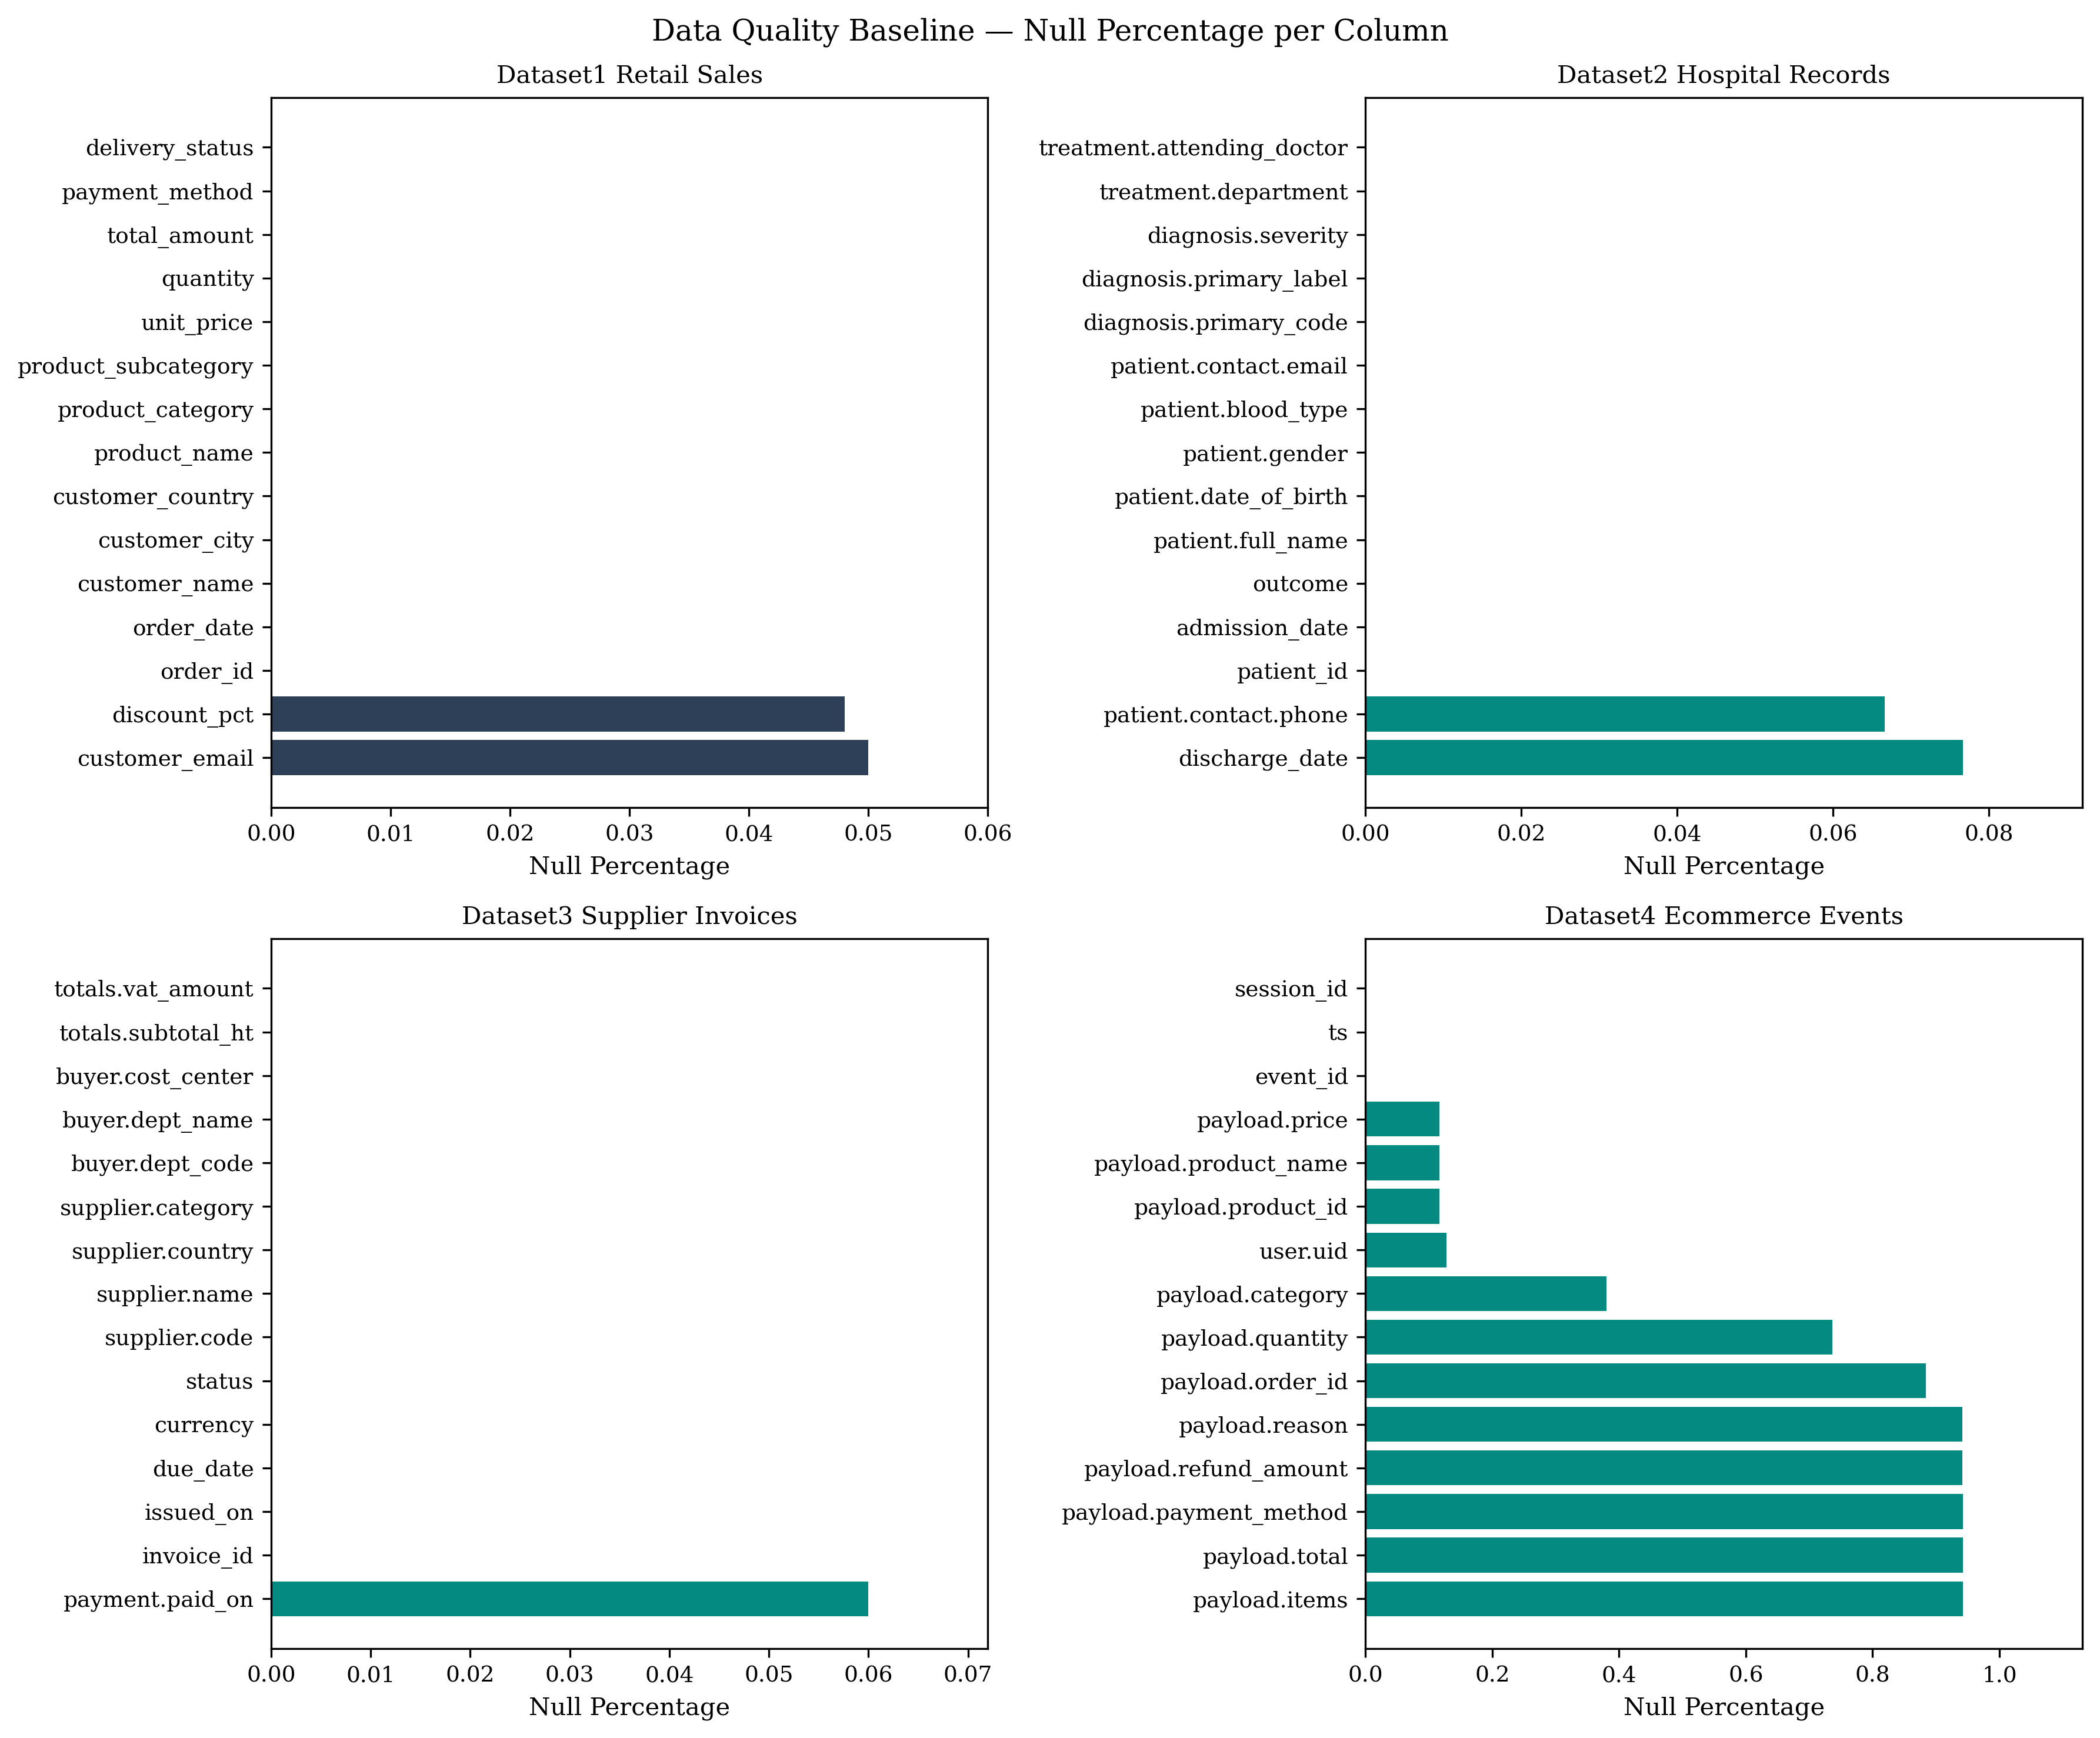

Saved: results/figures/fig0_dq_baseline.pdf


In [5]:
# Cell 4 — Data quality baseline visualization
import matplotlib.pyplot as plt
from src.visualizer import ResearchVisualizer

viz = ResearchVisualizer()

# Compute null percentages per column for each dataset
dq_data = {}
for name, df in datasets.items():
    short_name = name.split('.')[0]
    null_pcts = df.isnull().mean().to_dict()
    sorted_cols = sorted(null_pcts.items(), key=lambda x: x[1], reverse=True)[:15]
    dq_data[short_name] = dict(sorted_cols)

fig = viz.plot_dq_baseline(dq_data)
display(fig)
plt.close(fig)
print('Saved: results/figures/fig0_dq_baseline.pdf')

In [6]:
# Cell 5 — Save summary to JSON
os.makedirs('results/metrics', exist_ok=True)

summary = {
    'python_version': sys.version,
    'datasets': {},
}
for name, df in datasets.items():
    short = name.split('.')[0]
    summary['datasets'][short] = {
        'rows': len(df),
        'columns': len(df.columns),
        'missing_pct': float(df.isnull().mean().mean()),
        'difficulty': difficulties.get(name, 'unknown'),
    }

with open('results/metrics/00_setup.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved: results/metrics/00_setup.json')
print('\n✓ Notebook 00 complete.')

Saved: results/metrics/00_setup.json

✓ Notebook 00 complete.
